> **在线运行说明。** 下一格安装 `coptpy`。内置的免费许可有规模上限，但足够跑通本案例。然后执行「运行所有」。


In [ ]:
# COPT Python API and this case's dependencies
!pip install -q coptpy matplotlib


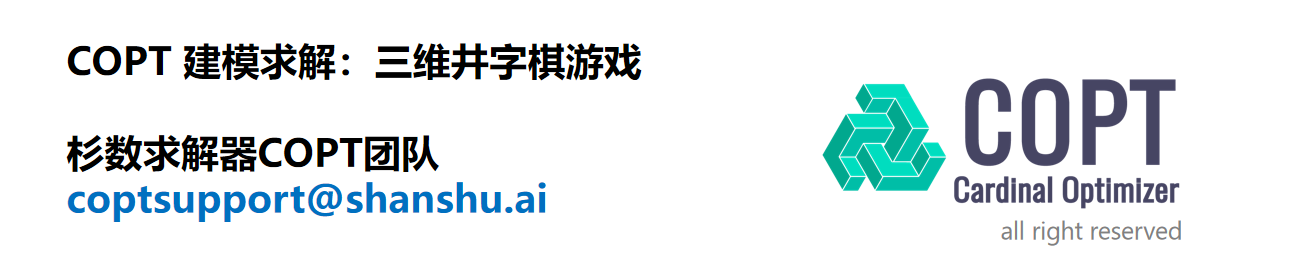

# 三维井字棋游戏代码实现
## 使用COPT建模求解三维井字棋游戏的步骤

1. **导入COPT-Python接口库** `coptpy`

2. 创建**求解环境**和求解**模型**

3. **构建模型：依次添加三要素**
    - **决策变量**
    - **目标函数**
    - **约束条件**

4. **求解**

5. 查看和分析求解**结果**

## COPT Python API求解 -- 线性规划问题

COPT是一款功能强大的优化求解器。你只需要将问题向COPT描述清楚（这里我们使用Python描述问题），COPT就能够帮你求解问题，告诉你问题的最优解以及相关信息。

想要使用COPT求解优化问题，需要先创建COPT环境，并在环境中创建一个模型，之后我们可以向模型中添加具体的问题刻画，最后由COPT将问题求解。

### 创建COPT环境

首先将COPT的Python API导入，COPT的Python API名称为coptpy。（需要注意的是，如果在本地使用coptpy，在安装COPT后还需要安装Python接口，具体见<a href="https://www.shanshu.ai/copt-document/manual?id=19&docType=3" target="_blank">COPT 手册</a>）

In [1]:
from coptpy import *

接下来创建COPT环境。我们使用`Envr()`函数创建COPT环境。

In [3]:
# Create COPT environment
env = Envr()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



在COPT环境中创建一个名为"lp_example"的模型。使用`createModel()`，它有一个参数`name`可以为模型命名。

In [5]:
# Create COPT model
model = env.createModel("lp_example")

我们可以通过`model.status`查看`model`的一些属性，目前模型还没有开始求解，所以是`COPT.UNSTARTED`。

In [7]:
model.status == COPT.UNSTARTED

True

更多模型可能的状态如下，包括：

| 模型求解的状态 | 含义 |
| :--- | :--- |
|`COPT.UNSTARTED`|未开始求解|
|`COPT.OPTIMAL`|成功求解|
|`COPT.INFEASIBLE`|模型无解|
|`COPT.UNBOUNDED`|最优值无界|
|`COPT.INF_OR_UNB`|模型无解或最优值无界|
|`COPT.NUMERICAL`|求解遇到数值问题|
|`COPT.NODELIMIT`|节点限制前未成功求解|
|`COPT.TIMEOUT`|时间限制前未成功求解|
|`COPT.UNFINISHED`|求解终止。但由于数值问题，求解器无法给出结果|
|`COPT.INTERRUPTED`|用户中止|

In [9]:
(COPT.UNSTARTED, COPT.OPTIMAL, COPT.INFEASIBLE, \
 COPT.UNBOUNDED, COPT.INF_OR_UNB, COPT.NUMERICAL,\
 COPT.NODELIMIT, COPT.TIMEOUT, COPT.UNFINISHED, COPT.INTERRUPTED)

(0, 1, 2, 3, 4, 5, 6, 8, 9, 10)

### 向COPT描述问题

#### 添加决策变量与范围约束

使用`addVar()`依次添加决策变量$x,y,z$，这一步我们就可以通过设置参数`lb`和`ub`分别设置变量的下界和上界，从而加入变量的范围约束
$$
\begin{aligned}
&0.1\leq x \leq 0.6 \\
&0.2\leq y \leq 1.5 \\
&0.3\leq z \leq 2.8
\end{aligned}
$$
`lb`和`ub`默认分别是`0`和`COPT.INFINITY`，即变量默认$\geq 0$。

在模型中设置参数`name`可以为变量命名（注意这里指的不是Python代码中的变量名，而是COPT模型中的变量名）。

In [11]:
# Add variables: x, y, z
x = model.addVar(lb=0.1, ub=0.6, name="x")
y = model.addVar(lb=0.2, ub=1.5, name="y")
z = model.addVar(lb=0.3, ub=2.8, name="z")

我们查看Python中的`x`变量，发现COPT已经知道它是名为$x$的决策变量。

In [13]:
x

<coptpy.Var: x>

#### 添加剩余约束

使用`addConstr()`依次添加剩余约束
$$
\begin{aligned}
&1.5x + 1.2y + 1.8z \leq 2.6 \\
&0.8x + 0.6y + 0.9z \geq 1.2
\end{aligned}
$$

这里`addConstr()`的参数是由变量形成的表达式。可以有两种方式添加约束的表达式

|约束|coptpy语法|copty常量|
|:---:|:---:|:---:|
|$\leq$|`<=`|`COPT.LESS_EQUAL`|
|$\geq$|`>=`|`COPT.GREATER_EQUAL`|
|$=$|`==`|`COPT.EQUAL`|

直接使用coptpy语法添加约束

In [15]:
# Add constraints
model.addConstr(1.5*x + 1.2*y + 1.8*z <= 2.6)
model.addConstr(0.8*x + 0.6*y + 0.9*z >= 1.2)

<coptpy.Constraint: >

或使用coptpy常量，这与上面使用coptpy语法的效果相同

In [17]:
# Another way to add constraints
# model.addConstr(1.5*x + 1.2*y + 1.8*z, COPT.LESS_EQUAL, 2.6)
# model.addConstr(0.8*x + 0.6*y + 0.9*z, COPT.GREATER_EQUAL, 1.2)

##### 设定目标函数

使用`setObjective()`可以设定目标函数的表达式
$$
\max\ 1.2x + 1.8y + 2.1z
$$
`sense`参数确定问题是最大化问题（`COPT.MAXIMIZE`）还是最小化问题（`COPT.MINIMIZE`）。

In [19]:
model.setObjective(1.2*x + 1.8*y + 2.1*z, sense=COPT.MAXIMIZE)

##### 设定求解器参数

其实，至此我们已经将问题向COPT描述清楚了。

但有时，我们会通过`setParam()`设定一些求解器参数，向COPT求解器提出某些求解要求。这里我们不希望等待过多时间，如果COPT求解时间超过10秒，就让COPT自动停止。

COPT的`COPT.Param`中有许多参数可以设定，这里我们将`COPT.Param.TimeLimit`参数设定为10以实现需求。

In [21]:
# Set parameter
model.setParam(COPT.Param.TimeLimit, 10.0)

Setting parameter 'TimeLimit' to 10


### 求解线性规划

万事俱备，只欠东风！

我们来求解该线性规划问题。求解模型很简单，只需使用`solve()`即可。

In [23]:
# Solve the model
model.solve()

Model fingerprint: 23f5362b

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Maximizing an LP problem

The original problem has:
    2 rows, 3 columns and 6 non-zero elements
The presolved problem has:
    2 rows, 3 columns and 6 non-zero elements

Starting the simplex solver using up to 8 threads

Problem info:
    Range of matrix coefficients:    [6e-01,2e+00]
    Range of rhs coefficients:       [1e+00,3e+00]
    Range of bound coefficients:     [1e-01,3e+00]
    Range of cost coefficients:      [1e+00,2e+00]

Method   Iteration           Objective  Primal.NInf   Dual.NInf        Time
Dual             0    6.2083756300e+00            1           0       0.03s
Dual             1    3.5783473899e+00            0           0       0.03s

Solving finished
Status: Optimal  Objective: 3.5783333333e+00  Iterations: 1  Time:

### 查看并存储求解结果

查看模型状态，发现此时模型已经被求解了。

In [25]:
model.status == COPT.OPTIMAL

True

查看最优解和最优值的相关信息。`getVars()`能够获取全部的变量，`var.name`能够获取变量的名称，`var.x`能够获取变量的最优值。

In [27]:
# Analyze solution
if model.status == COPT.OPTIMAL:
    print('Objective value: {}'.format(model.objval))
    print('Solving Time: {} seconds'.format(model.SolvingTime))
    
    allvars = model.getVars()
    
    print('Variable solution:')
    for var in allvars:
        print('{0}: {1}'.format(var.name, var.x))
        
    print('Variable basis status:')
    for var in allvars:
        print('{0}: {1}'.format(var.name, var.basis))

Objective value: 3.578333333333334
Solving Time: 0.034999847412109375 seconds
Variable solution:
x: 0.1
y: 1.5
z: 0.3611111111111113
Variable basis status:
x: 0
y: 2
z: 1


我们还可以用`write()`将优化问题存为.mps文件，将COPT求解的的最优值和最优解存为.sol文件，将最优解的基解文件存为.bas文件，将模型参数存为.par文件等。COPT会智能地识别文件格式，存储相应的内容。

具体写法如下
```python
# Write model, solution and modified parameters to file
model.write('lp_example.mps')
model.write('lp_example.bas')
model.write('lp_example.sol')
model.write('lp_example.par')
```

其中，值得一提的是，.mps文件格式是优化领域通用的存储优化问题的文件格式之一。存储之后，下次可以使用COPT直接读取.mps格式的问题，而不用`addVar()`和`addConstr()`等麻烦地添加变量或约束。

### 小结

我们使用`Envr()`和`Envr.createModel()`分别创建了COPT环境与环境中的模型。然后使用了`Model.addVar()`、`Model.addConstr()`和`Model.setObjective()`分别向COPT描述了优化问题的决策变量、约束和目标函数与优化方向，并使用`Model.setParam()`对优化的时间提出了限制。使用`Model.solve()`求解模型后，我们使用`Model.getVars()`获取了决策变量，通过访问模型与决策变量的各种属性，查看了最优解、求解时间和最优值等信息。

至此，我们已经能够自行建立并求解小规模线性规划问题了!

然而，直接使用`Model.addVar()`以及`Model.addConstr()`只能依次添加单个决策变量与约束，当我们希望**批量添加决策变量和约束**时，它们显得有些麻烦（需要使用Python的循环语句）。COPT Python API为我们提供了更为方便的`Model.addVars()`和`Model.addConstrs()`。下面的案例介绍了`Model.addVars()`的使用，`Model.addConstrs()`则可以参考<a href="https://www.shanshu.ai/copt-document/manual?id=19&docType=3" target="_blank">COPT Python API</a>。

另一方面，在整数规划中，常常遇见**指示变量**与**指示约束**。指示变量的取值决定了是否选取或实现某些选项，而指示约束与指示变量相关，往往是在指示变量取某值时才会起作用的约束。COPT提供了`Model.addGenConstrIndicator()`添加指示约束。

在接下来的三维井字棋的示例中（这是个整数规划问题），我们会学习这些函数的使用，为之后解决实际的复杂的优化问题做准备。

---

## COPT Python API求解 -- 三维井字棋

我们导入COPT的Python模块，并创建环境和模型。

In [29]:
from coptpy import *

env = Envr()
model = env.createModel('Tic_Tac_Toe')

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



### 模型设计

我们先创建一个包含三维棋盘所有可能直线的列表。每条直线由一个Python的三维元组（tuple）表示，元组的每一个分量代表了相关格子的位置坐标$(i,j,k)$。共有49条直线。

In [31]:
lines = []
size = 3

for i in range(size):
    for j in range(size):
        for k in range(size):
            if i == 0:
                lines.append(((0,j,k), (1,j,k), (2,j,k)))
            if j == 0:
                lines.append(((i,0,k), (i,1,k), (i,2,k)))
            if k == 0:
                lines.append(((i,j,0), (i,j,1), (i,j,2)))
            if i == 0 and j == 0:
                lines.append(((0,0,k), (1,1,k), (2,2,k)))
            if i == 0 and j == 2:
                lines.append(((0,2,k), (1,1,k), (2,0,k)))
            if i == 0 and k == 0:
                lines.append(((0,j,0), (1,j,1), (2,j,2)))
            if i == 0 and k == 2:
                lines.append(((0,j,2), (1,j,1), (2,j,0)))
            if j == 0 and k == 0:
                lines.append(((i,0,0), (i,1,1), (i,2,2)))
            if j == 0 and k == 2:
                lines.append(((i,0,2), (i,1,1), (i,2,0)))
lines.append(((0,0,0), (1,1,1), (2,2,2)))
lines.append(((2,0,0), (1,1,1), (0,2,2)))
lines.append(((0,2,0), (1,1,1), (2,0,2)))
lines.append(((0,0,2), (1,1,1), (2,2,0)))

len(lines)

49

接下来我们创建我们的模型并添加决策变量。这里使用`Model.addVars(*indices,lb=0.0,ub=COPT.INFINITY,obj=0.0,vtype=COPT.CONTINUOUS,nameprefix="C")`批量添加$isX$和$isLine$，其中`*indices`是变量的维度，也可取成元组组成的列表，生成对应下标的变量。

注意这里的$isX$和$isLine$都是0-1整数变量，而`addVars()`默认添加的是`COPT.CONTINUOUS`变量，所以这里我们需要声明`vtype=COPT.BINARY`。以下是COPT中的变量类型。

|变量类型|coptpy常量|
|:---|:---:|
|连续型变量|`COPT.CONTINUOUS`（默认）|
|0-1整数变量|`COPT.BINARY`|
|整数变量|`COPT.INTEGER`|

`addVars()`会返回COPT封装的tupledict类型的对象，对这一类对象，COPT提供了方便的函数取操作它。

In [33]:
isX = model.addVars(size, size, size, vtype=COPT.BINARY, nameprefix="isX")
isLine = model.addVars(lines, vtype=COPT.BINARY, nameprefix="isLine")

现在我们添加约束。第一个约束表示棋盘应该包含14个$X$（和13个$O$）。
$$
\begin{equation*}
\sum_{ijk} \text{isX}_{ijk} = 14
\end{equation*}
$$

其中$isX$是COPT的tupledict对象，COPT提供了方便的`sum()`函数对其求和。

如果要对全部$isX$的全部变量求和可以使用

In [35]:
isX.sum()

0.0 + <coptpy.Var: isX(0,0,0)> + <coptpy.Var: isX(0,0,1)> + <coptpy.Var: isX(0,0,2)> + <coptpy.Var: isX(0,1,0)> + <coptpy.Var: isX(0,1,1)> + <coptpy.Var: isX(0,1,2)> + <coptpy.Var: isX(0,2,0)> + <coptpy.Var: isX(0,2,1)> + <coptpy.Var: isX(0,2,2)> + <coptpy.Var: isX(1,0,0)> + <coptpy.Var: isX(1,0,1)> + <coptpy.Var: isX(1,0,2)> + <coptpy.Var: isX(1,1,0)> + <coptpy.Var: isX(1,1,1)> + <coptpy.Var: isX(1,1,2)> + <coptpy.Var: isX(1,2,0)> + <coptpy.Var: isX(1,2,1)> + <coptpy.Var: isX(1,2,2)> + <coptpy.Var: isX(2,0,0)> + <coptpy.Var: isX(2,0,1)> + <coptpy.Var: isX(2,0,2)> + <coptpy.Var: isX(2,1,0)> + <coptpy.Var: isX(2,1,1)> + <coptpy.Var: isX(2,1,2)> + <coptpy.Var: isX(2,2,0)> + <coptpy.Var: isX(2,2,1)> + <coptpy.Var: isX(2,2,2)> 

这里我们使用`isX.sum() == 14`即可，如下加入约束

In [37]:
x14 = model.addConstr(isX.sum() == 14)

剩余约束建立了$isLine[]$和$isX[]$的关系。一条直线形成“连线”当且仅当它的三个格子符号一致。在我们的模型中，这和三个对应的$isX[]$变量有关。当三个符号都是$X$时，$isX[]$和为3；当三个符号都是$O$时，$isX[]$和为0。于是，我们只需在约束中要求如果$isLine[] = 0$，则对应的$isX[]$的和必须严格大于0且小于3（即大于等于1且小于等于2）。

$$
\begin{equation*}
\text{isLine}_l == 0 \implies 1 <= isX[l_0] + isX[l_1] + isX[l_2] <= 2 \quad \forall l \in \text{Lines}
\end{equation*}
$$

`Model.addGenConstrIndicator(binvar,binval,lhs,sense=None,rhs=None)`表示当指示变量`binvar`为`binval`时，后面的约束要成立，否则后面的约束可以违背。

In [39]:
for line in lines:
    model.addGenConstrIndicator(isLine[line], False, isX[line[0]] + isX[line[1]] + isX[line[2]] >= 1)
    model.addGenConstrIndicator(isLine[line], False, isX[line[0]] + isX[line[1]] + isX[line[2]] <= 2)

最后，我们设置目标函数的表达式和优化方向，即最小化“连线”数。

In [41]:
model.setObjective(isLine.sum(), COPT.MINIMIZE)

现在我们进行优化求解。

In [43]:
model.solve()

Model fingerprint: e5d497cc

Using Cardinal Optimizer v8.0.5 on Windows (22H2 Build 19045 - x86_64)
The CPU model is Intel(R) Core(TM) i5-10210U CPU @ 1.60GHz
Hardware has 4 physical cores and 8 logical cores. Using instruction set X86_AVX2 (10)
Minimizing a MIP problem

The original problem has:
    1 rows, 76 columns and 27 non-zero elements
    76 binaries
    98 indicators

Starting the MIP solver with 8 threads and 32 tasks

Presolving the problem

The presolved problem has:
    99 rows, 76 columns and 419 non-zero elements
    76 binaries

Problem info:
    Range of matrix coefficients:    [1e+00,1e+00]
    Range of rhs coefficients:       [1e+00,1e+01]
    Range of bound coefficients:     [1e+00,1e+00]
    Range of cost coefficients:      [1e+00,1e+00]
    Density of cost:                     64.5%

     Nodes    Active  LPit/n  IntInf     BestBound  BestSolution     Gap   Time
         0         1      --       0  0.000000e+00            --     Inf  0.06s
         0         1  

### 结果

最优解仅形成了4条“连线”。我们使用`matplotlib`可视化展示结果，蓝色表示放置了$X$，白色表示放置了$O$（这里不展示棋盘的第三维）。

Objective value: 4.0


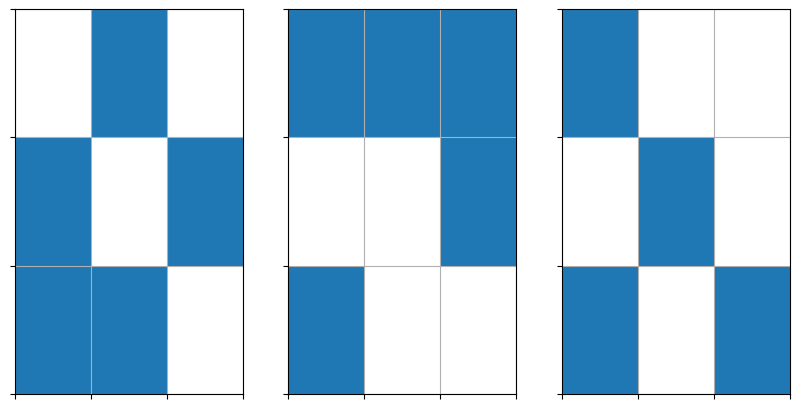

In [45]:
import matplotlib.pyplot as plt
%matplotlib inline

if model.status == COPT.OPTIMAL:
    print('Objective value: {}'.format(model.objval))

fig, ax = plt.subplots(1, 3, figsize=(10,5))
for i in range(3):
    ax[i].grid()
    ax[i].set_xticks(range(4))
    ax[i].set_yticks(range(4))
    ax[i].tick_params(labelleft=False, labelbottom=False)
    
for cell in isX.keys():
    if isX[cell].x > 0.5:
        ax[cell[0]].add_patch(plt.Rectangle((cell[1],cell[2]), 1, 1))

plt.show()

---

## 拓展

### `tupledict.sum()`的使用

在求解三维井字棋问题时，我们使用了`isX.sum()`来加入约束
$$
\begin{equation*}
\sum_{ijk} \text{isX}_{ijk} = 14
\end{equation*}
$$

如果要计算
$$
\sum_{k} isX_{12k}
$$
可以使用`'*'`代表在该维度上求和

In [47]:
isX.sum(1,2,'*')

0.0 + <coptpy.Var: isX(1,2,0)> + <coptpy.Var: isX(1,2,1)> + <coptpy.Var: isX(1,2,2)> 

如果要计算
$$
\sum_{i\in\{1,2\}}\sum_{k}isX_{i1k}
$$
则可以使用

In [49]:
isX.sum([1,2],1,'*')

0.0 + <coptpy.Var: isX(1,1,0)> + <coptpy.Var: isX(1,1,1)> + <coptpy.Var: isX(1,1,2)> + <coptpy.Var: isX(2,1,0)> + <coptpy.Var: isX(2,1,1)> + <coptpy.Var: isX(2,1,2)> 